In [1]:
!pip install -q tensorflow tensorflow-hub pillow matplotlib numpy

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)

Saving Screenshot 2026-09-24 225052.png to Screenshot 2026-09-24 225052.png
Uploaded image: Screenshot 2026-09-24 225052.png


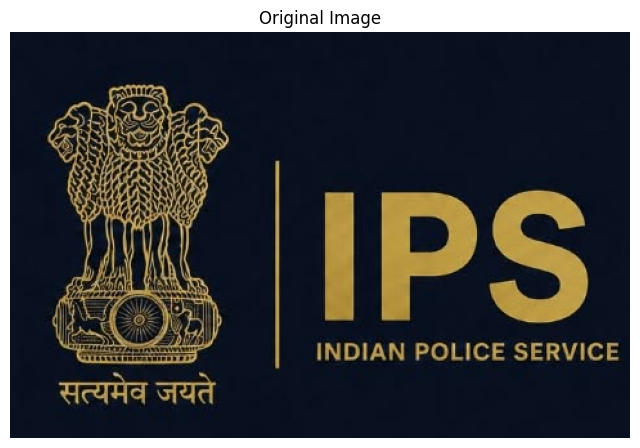

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

original_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [5]:
def load_image(image_path, max_dim=512):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    shape = tf.cast(tf.shape(image)[:-1], tf.float32)
    long_dim = max(shape)

    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    image = tf.image.resize(image, new_shape)
    image = image[tf.newaxis, :]

    return image

content_image = load_image(image_path)

print("Image shape:", content_image.shape)

Image shape: (1, 335, 512, 3)


In [6]:
!wget -q https://www.kaggle.com/api/v1/datasets/download/balraj98/horse2zebra-cyclegan-model -O cyclegan.zip
!unzip -q cyclegan.zip -d cyclegan_model

[cyclegan.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of cyclegan.zip or
        cyclegan.zip.zip, and cannot find cyclegan.zip.ZIP, period.


In [7]:
!find cyclegan_model -maxdepth 3 -type f | head -20

find: ‘cyclegan_model’: No such file or directory


In [8]:
import os

for root, dirs, files_list in os.walk("cyclegan_model"):
    for file in files_list:
        print(os.path.join(root, file))

In [10]:
def prepare_cyclegan_image(image_path, size=(256, 256)):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    image = tf.image.resize(image, size)

    image = image * 2.0 - 1.0

    image = image[tf.newaxis, ...]

    return image

cycle_input = prepare_cyclegan_image(image_path)

print(cycle_input.shape)

(1, 256, 256, 3)


In [15]:
!git clone https://github.com/tensorflow/gan.git

Cloning into 'gan'...
remote: Enumerating objects: 4708, done.
remote: Counting objects: 100% (1253/1253), done.
remote: Compressing objects: 100% (441/441), done.
remote: Total 4708 (delta 870), reused 1144 (delta 809), pack-reused 3455 (from 1)
Receiving objects: 100% (4708/4708), 53.01 MiB | 24.29 MiB/s, done.
Resolving deltas: 100% (3375/3375), done.


In [16]:
!pip install -q tensorflow-gan tensorflow-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 8.5 MB/s eta 0:00:00


In [17]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
!git clone https://github.com/tensorflow/models.git

Cloning into 'models'...
remote: Enumerating objects: 106520, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 106520 (delta 2), reused 0 (delta 0), pack-reused 106507 (from 2)
Receiving objects: 100% (106520/106520), 644.82 MiB | 29.45 MiB/s, done.
Resolving deltas: 100% (77139/77139), done.


In [20]:
!pip install -q tensorflow-datasets tensorflow-gan

In [21]:
!wget -q https://people.eecs.berkeley.edu/~taesung_park/CycleGAN/datasets/horse2zebra.zip
!unzip -q horse2zebra.zip

unzip:  cannot find or open horse2zebra.zip, horse2zebra.zip.zip or horse2zebra.zip.ZIP.


In [23]:
!wget -O horse2zebra.zip https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip

--2026-10-01 06:41:13--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘horse2zebra.zip’

horse2zebra.zip     100%[===================>] 111.45M   133MB/s    in 0.8s    

2026-10-01 06:41:14 (133 MB/s) - ‘horse2zebra.zip’ saved [116867962/116867962]



In [24]:
!unzip -q horse2zebra.zip

In [25]:
!ls -la

total 114316
drwxr-xr-x  1 root root      4096 Oct  1 06:41  .
drwxr-xr-x  1 root root      4096 Oct  1 06:21  ..
drwxr-xr-x  4 root root      4096 Sep  4 13:32  .config
-rw-r--r--  1 root root         0 Oct  1 06:33  cyclegan.zip
drwxr-xr-x  4 root root      4096 Oct  1 06:37  gan
drwxrwxr-x  6 root root      4096 Mar 10  2017  horse2zebra
-rw-r--r--  1 root root 116867962 May  1  2021  horse2zebra.zip
drwxr-xr-x 10 root root      4096 Oct  1 06:39  models
drwxr-xr-x  1 root root      4096 Sep  4 13:32  sample_data
-rw-r--r--  1 root root    158490 Oct  1 06:32 'Screenshot 2026-09-24 225052.png'


In [26]:
!ls horse2zebra

testA  testB  trainA  trainB


In [27]:
!rm -rf pytorch-CycleGAN-and-pix2pix
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 33.73 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [29]:
%cd /content

/content


In [30]:
!pwd

/content


In [31]:
!rm -rf pytorch-CycleGAN-and-pix2pix

In [32]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 13.30 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [33]:
!ls -la /content/pytorch-CycleGAN-and-pix2pix

total 112
drwxr-xr-x 11 root root  4096 Oct  1 07:00 .
drwxr-xr-x  1 root root  4096 Oct  1 07:00 ..
-rw-r--r--  1 root root  8001 Oct  1 07:00 CycleGAN.ipynb
drwxr-xr-x  2 root root  4096 Oct  1 07:00 data
drwxr-xr-x  3 root root  4096 Oct  1 07:00 datasets
drwxr-xr-x  2 root root  4096 Oct  1 07:00 docs
-rw-r--r--  1 root root   284 Oct  1 07:00 environment.yml
drwxr-xr-x  8 root root  4096 Oct  1 07:00 .git
-rw-r--r--  1 root root   768 Oct  1 07:00 .gitignore
drwxr-xr-x  2 root root  4096 Oct  1 07:00 imgs
-rw-r--r--  1 root root  3565 Oct  1 07:00 LICENSE
drwxr-xr-x  2 root root  4096 Oct  1 07:00 models
drwxr-xr-x  2 root root  4096 Oct  1 07:00 options
-rw-r--r--  1 root root  7122 Oct  1 07:00 pix2pix.ipynb
-rw-r--r--  1 root root 16743 Oct  1 07:00 README.md
-rw-r--r--  1 root root   795 Oct  1 07:00 .replit
drwxr-xr-x  4 root root  4096 Oct  1 07:00 scripts
-rw-r--r--  1 root root  4258 Oct  1 07:00 test.py
-rw-r--r--  1 root root  4777 Oct  1 07:00 train.py
drwxr-xr-x  2 roo

In [34]:
!pip install -q torch torchvision
!pip install -q dominate visdom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 28.3 MB/s eta 0:00:00


In [35]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!bash ./scripts/download_cyclegan_model.sh horse2zebra

/content/pytorch-CycleGAN-and-pix2pix
Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]
for details.

--2026-10-01 07:01:09--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

./checkpoints/horse 100%[===================>]  43.46M  50.9MB/s    in 0.9s    

2026-10-01 07:01:10 (50.9 MB/s) - ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pt

In [36]:
%cd /content

/content


In [37]:
!find /content -type f | grep horse2zebra | head -20

/content/horse2zebra.zip
/content/horse2zebra/testA/n02381460_4650.jpg
/content/horse2zebra/testA/n02381460_4470.jpg
/content/horse2zebra/testA/n02381460_4160.jpg
/content/horse2zebra/testA/n02381460_1660.jpg
/content/horse2zebra/testA/n02381460_4120.jpg
/content/horse2zebra/testA/n02381460_6690.jpg
/content/horse2zebra/testA/n02381460_2120.jpg
/content/horse2zebra/testA/n02381460_2890.jpg
/content/horse2zebra/testA/n02381460_7500.jpg
/content/horse2zebra/testA/n02381460_2580.jpg
/content/horse2zebra/testA/n02381460_6790.jpg
/content/horse2zebra/testA/n02381460_1110.jpg
/content/horse2zebra/testA/n02381460_690.jpg
/content/horse2zebra/testA/n02381460_2710.jpg
/content/horse2zebra/testA/n02381460_1000.jpg
/content/horse2zebra/testA/n02381460_8900.jpg
/content/horse2zebra/testA/n02381460_840.jpg
/content/horse2zebra/testA/n02381460_6640.jpg
/content/horse2zebra/testA/n02381460_4800.jpg


In [38]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Image:", image_path)

Saving genai a.jpg to genai a.jpg
Image: genai a.jpg


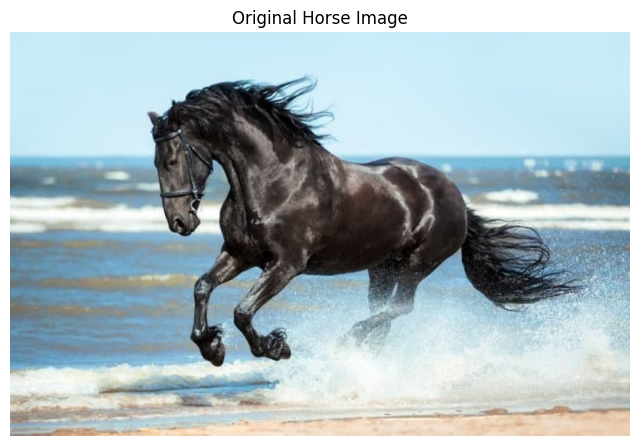

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.title("Original Horse Image")
plt.axis("off")
plt.show()

In [40]:
!rm -rf /content/cyclegan_test
!mkdir -p /content/cyclegan_test/testA

In [41]:
import shutil
import os

shutil.copy(
    image_path,
    "/content/cyclegan_test/testA/input.jpg"
)

print("Input image prepared.")

Input image prepared.


In [42]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!python test.py \
--dataroot /content/cyclegan_test \
--name horse2zebra_pretrained \
--model test \
--no_dropout

/content/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/cyclegan_test        	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
     

In [43]:
%cd /content

/content


In [44]:
!find /content/results -type f

find: ‘/content/results’: No such file or directory


In [45]:
import glob

cycle_files = glob.glob(
    "/content/results/horse2zebra_pretrained/test_latest/images/*fake*"
)

print(cycle_files)

[]


In [47]:
import os

print("Searching for CycleGAN output files...")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "fake" in file.lower():
            print(os.path.join(root, file))

Searching for CycleGAN output files...
/content/models/official/vision/data/fake_feature_generator.py
/content/pytorch-CycleGAN-and-pix2pix/results/horse2zebra_pretrained/test_latest/images/input_fake.png


Found files:
/content/pytorch-CycleGAN-and-pix2pix/results/horse2zebra_pretrained/test_latest/images/input_fake.png

Using: /content/pytorch-CycleGAN-and-pix2pix/results/horse2zebra_pretrained/test_latest/images/input_fake.png


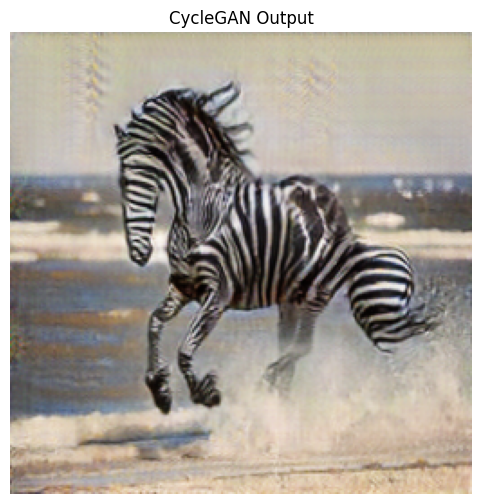

In [48]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

cycle_files = []

for pattern in [
    "/content/results/**/*fake*",
    "/content/pytorch-CycleGAN-and-pix2pix/results/**/*fake*"
]:
    cycle_files.extend(
        glob.glob(pattern, recursive=True)
    )

print("Found files:")
for f in cycle_files:
    print(f)

if len(cycle_files) == 0:
    print("\n❌ No CycleGAN output was found.")
    print("The CycleGAN test command did not generate an output image.")
else:
    cycle_path = cycle_files[0]

    print("\nUsing:", cycle_path)

    cycle_image = Image.open(
        cycle_path
    ).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(cycle_image)
    plt.title("CycleGAN Output")
    plt.axis("off")
    plt.show()

In [49]:
cycle_image.save("/content/cyclegan_output.jpg")
print("CycleGAN output saved successfully.")

CycleGAN output saved successfully.


In [50]:
import os
print(os.path.exists("/content/cyclegan_output.jpg"))

True


In [51]:
from google.colab import files

style_upload = files.upload()

style_path = list(style_upload.keys())[0]

print("Style image:", style_path)

Saving paintting.jpg to paintting.jpg
Style image: paintting.jpg


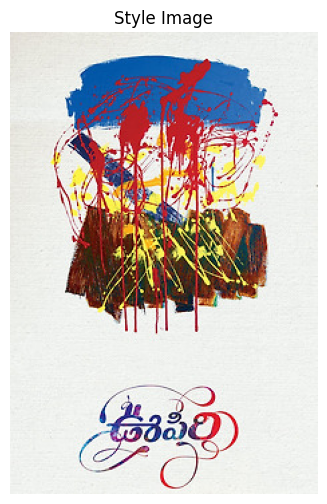

In [52]:
from PIL import Image
import matplotlib.pyplot as plt

style_display = Image.open(style_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(style_display)
plt.title("Style Image")
plt.axis("off")
plt.show()

In [53]:
import tensorflow as tf

def load_image(path, max_dim=512):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    shape = tf.cast(
        tf.shape(image)[:-1],
        tf.float32
    )

    long_dim = tf.reduce_max(shape)

    scale = max_dim / long_dim

    new_shape = tf.cast(
        shape * scale,
        tf.int32
    )

    image = tf.image.resize(
        image,
        new_shape
    )

    return image[tf.newaxis, :]

In [54]:
content_image = load_image(image_path)
style_image = load_image(style_path)

print("Content image:", content_image.shape)
print("Style image:", style_image.shape)

Content image: (1, 334, 512, 3)
Style image: (1, 512, 341, 3)


In [55]:
vgg = tf.keras.applications.VGG19(
    include_top=False,
    weights="imagenet"
)

print("VGG19 loaded successfully.")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG19 loaded successfully.


In [56]:
content_layers = [
    "block5_conv2"
]

style_layers = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1"
]

num_style_layers = len(style_layers)

print("Content layer:", content_layers)
print("Style layers:", style_layers)

Content layer: ['block5_conv2']
Style layers: ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']


In [57]:
outputs = [
    vgg.get_layer(name).output
    for name in style_layers + content_layers
]

feature_extractor = tf.keras.Model(
    vgg.input,
    outputs
)

feature_extractor.trainable = False

print("Feature extractor created.")

Feature extractor created.


In [58]:
def gram_matrix(input_tensor):

    result = tf.linalg.einsum(
        "bijc,bijd->bcd",
        input_tensor,
        input_tensor
    )

    input_shape = tf.shape(input_tensor)

    num_locations = tf.cast(
        input_shape[1] * input_shape[2],
        tf.float32
    )

    return result / num_locations

In [59]:
def get_features(image):

    image = image * 255.0

    image = tf.keras.applications.vgg19.preprocess_input(
        image
    )

    outputs = feature_extractor(image)

    style_outputs = outputs[:num_style_layers]

    content_outputs = outputs[num_style_layers:]

    style_features = [
        gram_matrix(x)
        for x in style_outputs
    ]

    style_dict = dict(
        zip(style_layers, style_features)
    )

    content_dict = dict(
        zip(content_layers, content_outputs)
    )

    return {
        "style": style_dict,
        "content": content_dict
    }

In [60]:
style_targets = get_features(
    style_image
)["style"]

content_targets = get_features(
    content_image
)["content"]

print("Features extracted successfully.")

Features extracted successfully.


In [61]:
generated_image = tf.Variable(
    content_image
)

print("Generated image:", generated_image.shape)

Generated image: (1, 334, 512, 3)


In [62]:
style_weight = 1e-2
content_weight = 1e4

In [63]:
def style_content_loss(outputs):

    style_outputs = outputs["style"]
    content_outputs = outputs["content"]

    style_loss = tf.add_n([
        tf.reduce_mean(
            (style_outputs[name] - style_targets[name]) ** 2
        )
        for name in style_outputs
    ])

    style_loss *= (
        style_weight / num_style_layers
    )

    content_loss = tf.add_n([
        tf.reduce_mean(
            (content_outputs[name] - content_targets[name]) ** 2
        )
        for name in content_outputs
    ])

    content_loss *= (
        content_weight / len(content_layers)
    )

    return style_loss + content_loss

In [66]:
# Step 27 - Training function

@tf.function
def train_step(image):

    with tf.GradientTape() as tape:

        outputs = get_features(image)

        loss = style_content_loss(outputs)

    gradients = tape.gradient(
        loss,
        image
    )

    optimizer.apply_gradients(
        [(gradients, image)]
    )

    image.assign(
        tf.clip_by_value(
            image,
            0.0,
            1.0
        )
    )

    return loss

In [70]:
!pip install -q tensorflow-hub

In [69]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [72]:
style_transfer_model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

print("Neural Style Transfer model loaded successfully!")

Neural Style Transfer model loaded successfully!


In [73]:
content_image = load_image(
    image_path,
    max_dim=512
)

print("Content image:", content_image.shape)

Content image: (1, 334, 512, 3)


In [74]:
style_image = load_image(
    style_path,
    max_dim=256
)

print("Style image:", style_image.shape)

Style image: (1, 256, 170, 3)


In [75]:
stylized_image = style_transfer_model(
    content_image,
    style_image
)[0]

In [78]:
import os

print(
    "CycleGAN output:",
    os.path.exists("/content/cyclegan_output.jpg")
)

print(
    "Neural Style Transfer output:",
    os.path.exists(
        "/content/neural_style_transfer_output.jpg"
    )
)

CycleGAN output: True
Neural Style Transfer output: False


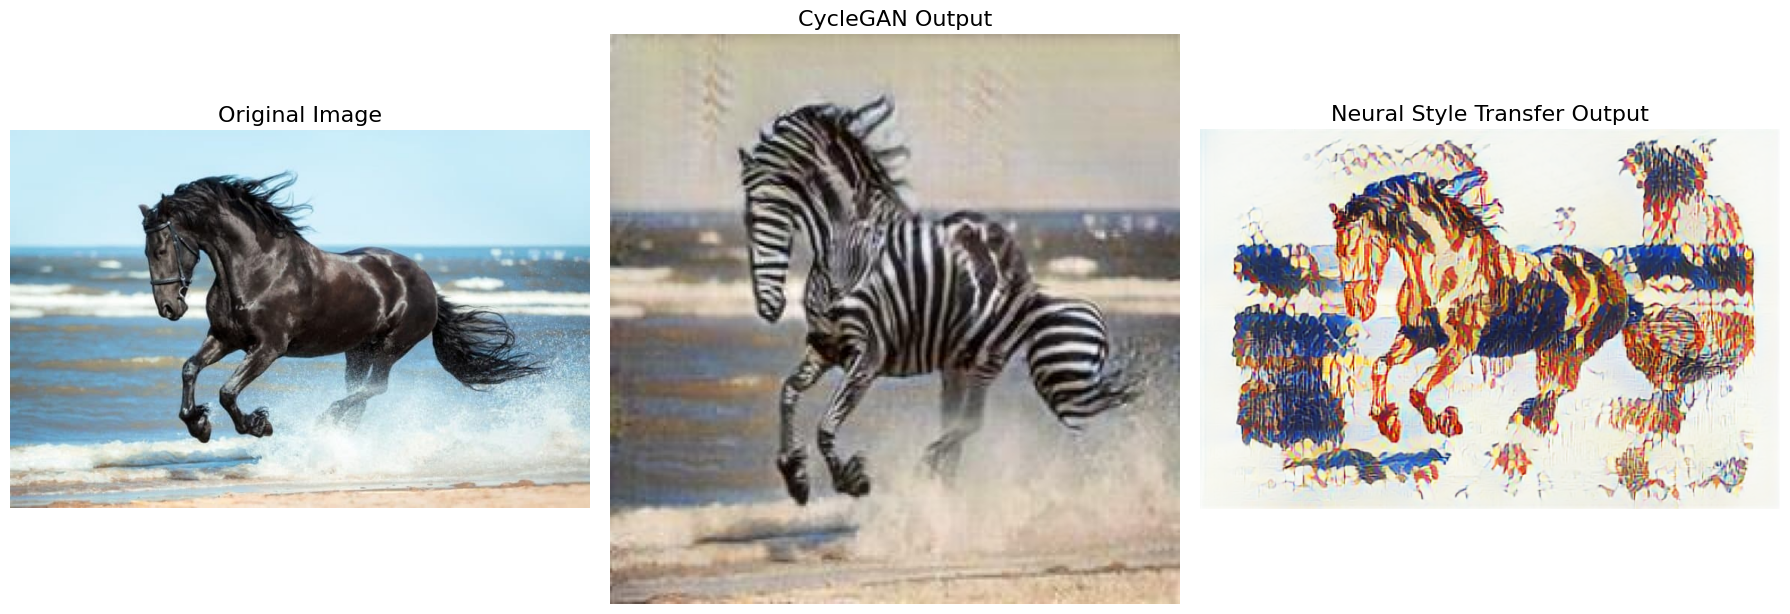

✅ Final comparison created successfully!


In [80]:
# STEP 36 - Final comparison

import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Original image
original_display = Image.open(image_path).convert("RGB")

# CycleGAN output
cycle_display = Image.open("/content/cyclegan_output.jpg").convert("RGB")

# Neural Style Transfer output
nst_display = stylized_image[0] if len(stylized_image.shape) == 4 else stylized_image

# Convert TensorFlow tensor to numpy
nst_display = nst_display.numpy()

# Make sure values are between 0 and 1
nst_display = tf.clip_by_value(
    nst_display,
    0.0,
    1.0
).numpy()

# Create comparison
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_display)
plt.title("Original Image", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cycle_display)
plt.title("CycleGAN Output", fontsize=16)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(nst_display)
plt.title("Neural Style Transfer Output", fontsize=16)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/Assignment6_Final_Comparison.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Final comparison created successfully!")

In [81]:
from google.colab import files

files.download(
    "/content/Assignment6_Final_Comparison.jpg"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>